In [16]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from photutils import DAOStarFinder
from astropy.stats import sigma_clipped_stats
from astropy.wcs.utils import proj_plane_pixel_scales
# from reproject import reproject_interp
from drizzle.drizzle import Drizzle

plt.style.use("science")

/tmp/ipykernel_31639/2015979404.py:8: DeprecationWarning: `photutils.DAOStarFinder` is a deprecated alias for `photutils.detection.DAOStarFinder` and will be removed in the future. Instead, please use `from photutils.detection import DAOStarFinder` to silence this warning.
  from photutils import DAOStarFinder


In [17]:
path = "../data/acs_I_095751+0228_unrot_sci_20.fits"
data = fits.open(path)

In [18]:
data.info()

Filename: ../data/acs_I_095751+0228_unrot_sci_20.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     539   (7500, 7500)   float32   


In [19]:
# data[0].header

In [20]:
wcs = WCS(data[0].header)
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 149.46484665  2.4824847  
CRPIX : 3750.0  3750.0  
CD1_1 CD1_2  : 1.4157228951629e-06  8.21219660800666e-06  
CD2_1 CD2_2  : 8.21219660800666e-06  -1.4157228951629e-06  
NAXIS : 7500  7500

In [21]:
wcs = WCS(data[0].header)

coord1 = SkyCoord("9:57:56.5294", "2:27:37.963", unit=(u.hourangle, u.deg))
coord2 = SkyCoord("9:57:46.8867", "2:28:22.735", unit=(u.hourangle, u.deg))
coord3 = SkyCoord("9:57:49.1102", "2:28:19.430", unit=(u.hourangle, u.deg))

In [22]:
coord1

<SkyCoord (ICRS): (ra, dec) in deg
    (149.48553917, 2.46054528)>

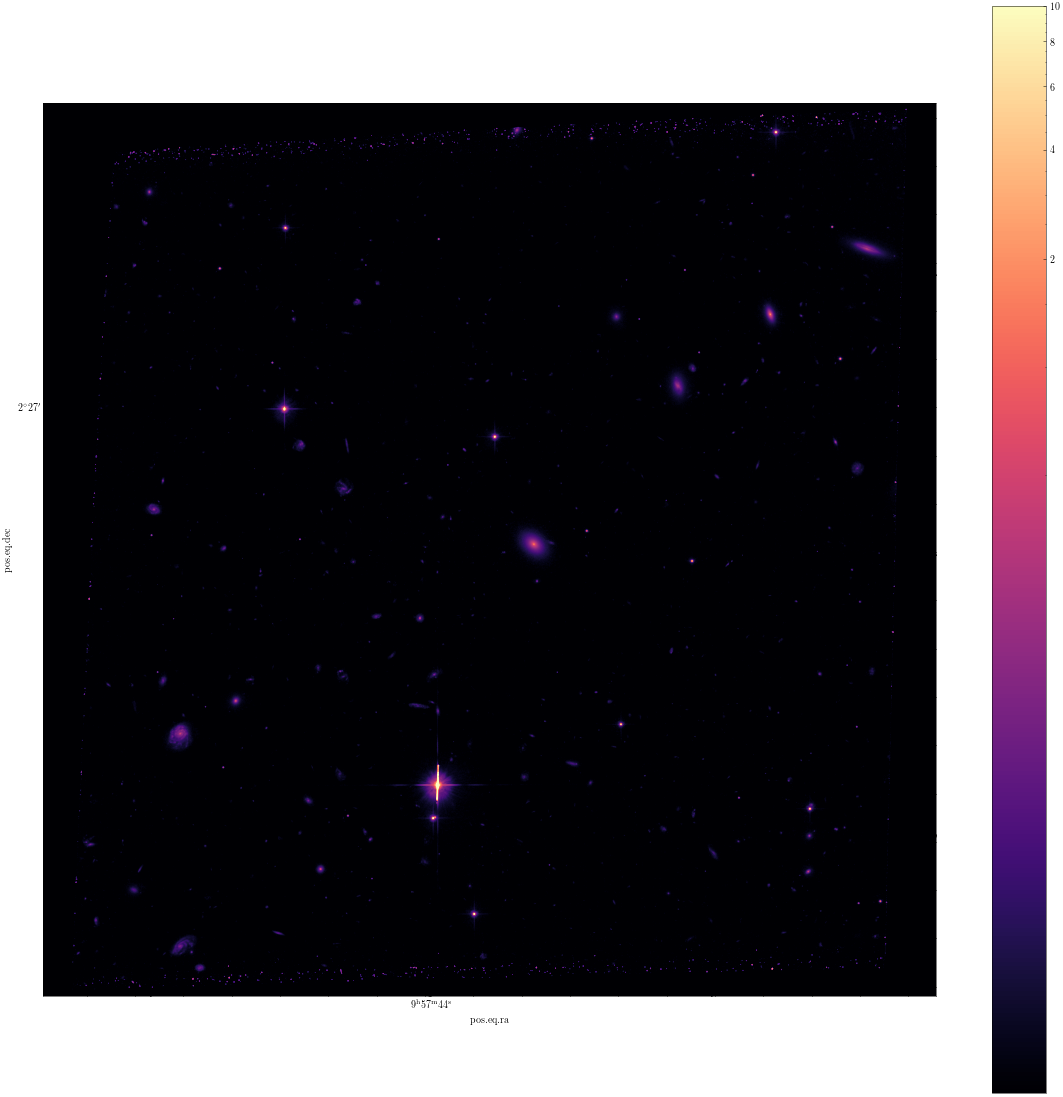

In [23]:
fig = plt.figure(figsize=(20, 20))
fig.add_subplot(projection=wcs)
plt.imshow(data[0].data, cmap="magma", norm=ImageNormalize(vmax=10, vmin=0.001, stretch=LogStretch()))
plt.colorbar()

In [24]:
size = 64 * u.pixel
cutout1 = Cutout2D(data[0].data, coord1, size, wcs=wcs)
cutout2 = Cutout2D(data[0].data, coord2, size, wcs=wcs)
cutout3 = Cutout2D(data[0].data, coord3, size, wcs=wcs)

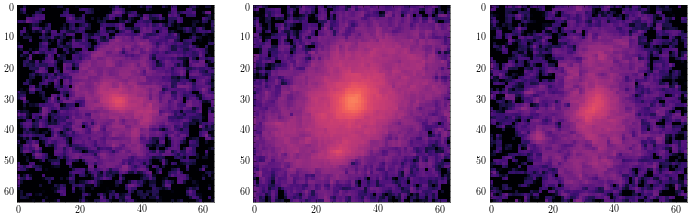

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(cutout1.data, cmap="magma", norm=ImageNormalize(vmax=1, vmin=0.001, stretch=LogStretch()))
axs[1].imshow(cutout2.data, cmap="magma", norm=ImageNormalize(vmax=1, vmin=0.001, stretch=LogStretch()))
axs[2].imshow(cutout3.data, cmap="magma", norm=ImageNormalize(vmax=1, vmin=0.001, stretch=LogStretch()))

# Raw data

In [26]:
# path = "../data/MAST_2023-05-25T19_15_30.001Z/HST/N8XTSEHUQ/n8xtsehuq_raw.fits"
# path = "../data/MAST_2023-05-25T19_15_30.001Z/HST/N8XTSEHUQ/n8xtsehuq_ima.fits"
path1 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybhq_raw.fits"
path2 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybkq_raw.fits"
path3 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybnq_raw.fits"
path4 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybyq_raw.fits"

dark_path = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/25716219j_drk.fits"
bias_path = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/6751858rj_bia.fits"


coord1_raw = SkyCoord("9:57:56.63", "2:27:36.7", unit=(u.hourangle, u.deg))
coord2_raw = SkyCoord("9:57:46.94", "2:28:22.735", unit=(u.hourangle, u.deg))
coord3_raw = SkyCoord("9:57:49.18", "2:28:19.3", unit=(u.hourangle, u.deg))
exptime = 2028

data = fits.open(path1)
pos1 = wcs.world_to_pixel(coord1_raw)
reference_wcs = WCS(data[4].header)
reference_cutout = Cutout2D(data[4].data, coord1_raw, size, wcs=reference_wcs)

cutouts1_raw = []
cutouts2_raw = []
cutouts3_raw = []

for p in [path1, path2, path3, path4]:
    data = fits.open(p)
    size = 64 * u.pixel
    wcs = WCS(data[4].header)
    cutout = Cutout2D(data[4].data, coord1_raw, size, wcs=wcs)
    # cutout, _ = reproject_interp((cutout.data, reference_wcs), reference_wcs, shape_out=[64, 64]) 
    cutouts1_raw.append(cutout)

    wcs = WCS(data[1].header)
    cutout = Cutout2D(data[1].data, coord2_raw, size, wcs=wcs)
    cutouts2_raw.append(cutout)
    
    cutout = Cutout2D(data[1].data, coord3_raw, size, wcs=wcs)
    cutouts3_raw.append(cutout)

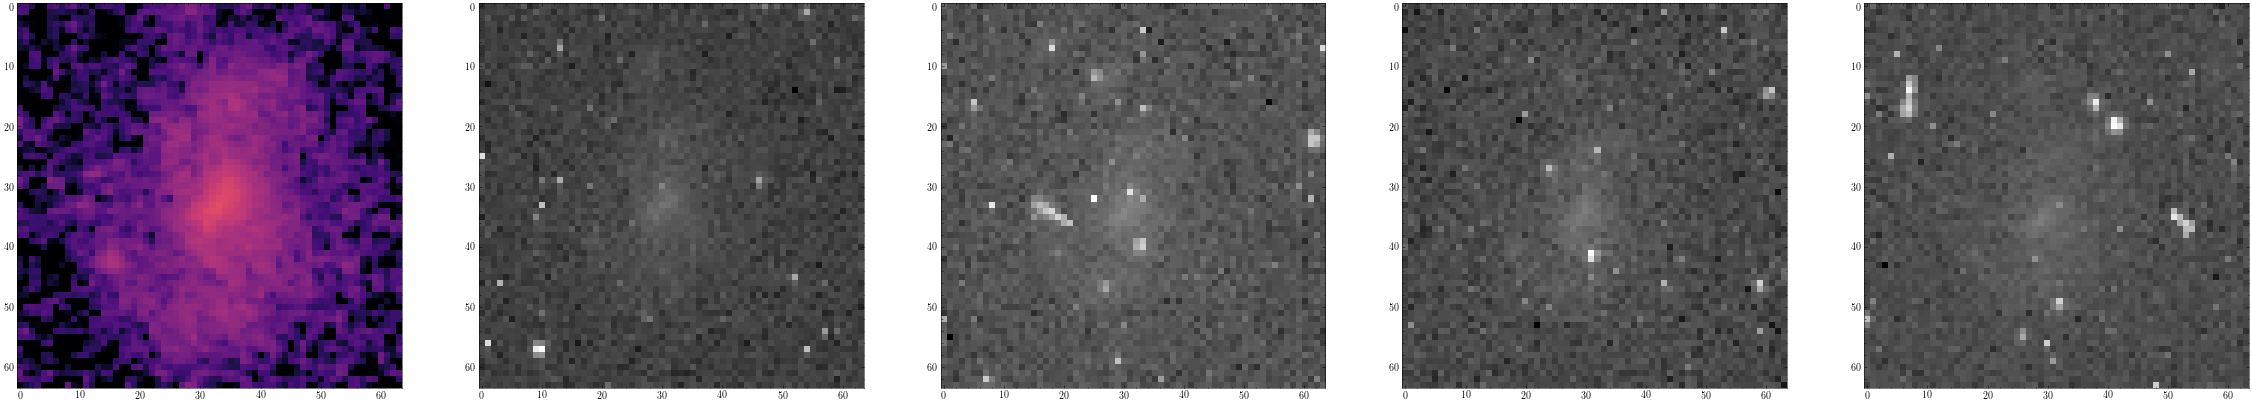

In [13]:
fig, axs = plt.subplots(1, 5, figsize=(40, 8))
axs[0].imshow(cutout3.data, cmap="magma", norm=ImageNormalize(vmax=1, vmin=0.001, stretch=LogStretch()))
for i, c in enumerate(cutouts3_raw):
    axs[i+1].imshow(c.data / exptime, cmap="gray", norm=ImageNormalize(stretch=LogStretch()))


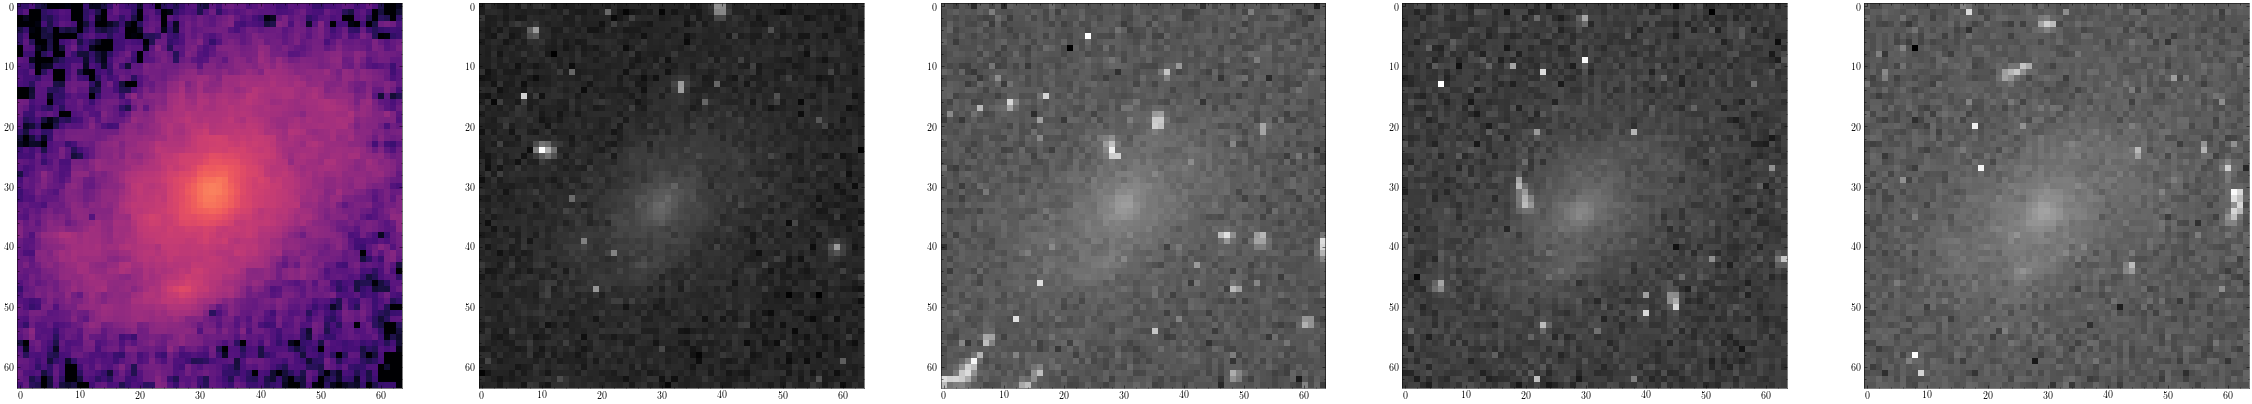

In [14]:
fig, axs = plt.subplots(1, 5, figsize=(40, 8))
axs[0].imshow(cutout2.data, cmap="magma", norm=ImageNormalize(vmax=1, vmin=0.001, stretch=LogStretch()))
for i, c in enumerate(cutouts2_raw):
    axs[i+1].imshow(c.data / exptime, cmap="gray", norm=ImageNormalize(stretch=LogStretch()))


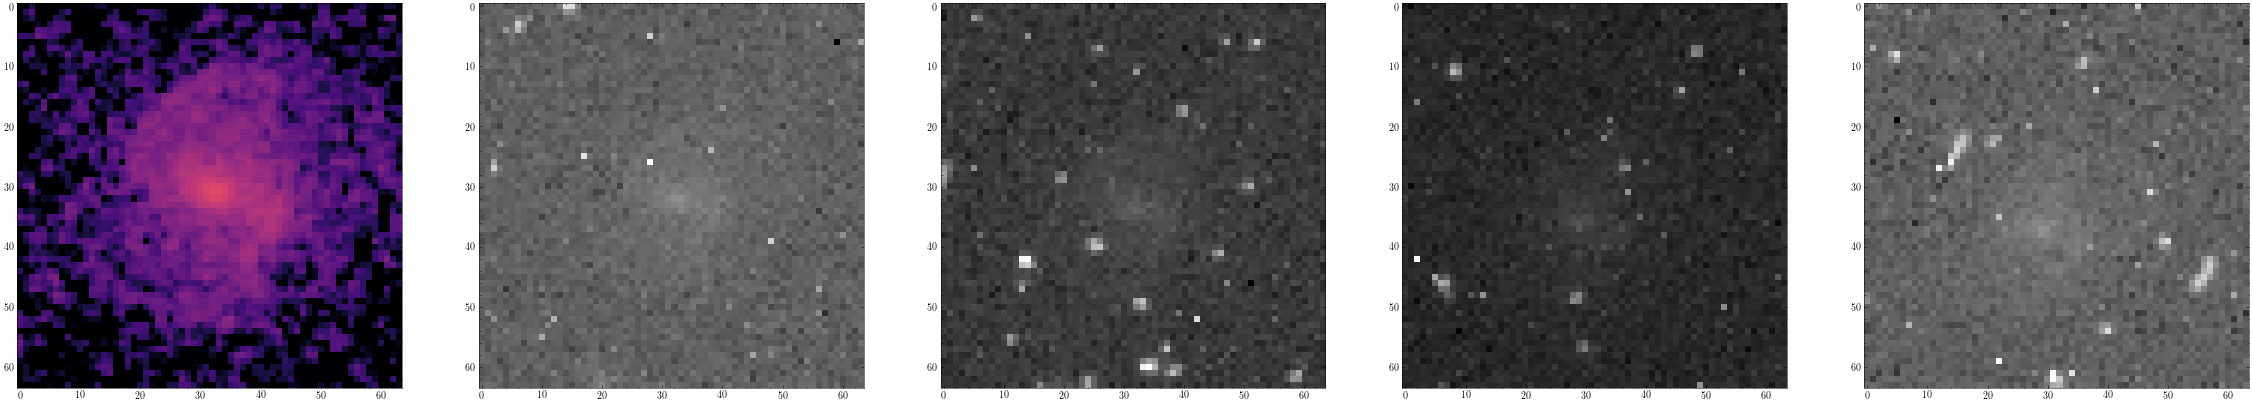

In [15]:
fig, axs = plt.subplots(1, 5, figsize=(40, 8))
axs[0].imshow(cutout1.data, cmap="magma", norm=ImageNormalize(vmax=1, vmin=0.001, stretch=LogStretch()))
for i, c in enumerate(cutouts1_raw):
    axs[i+1].imshow(c.data / exptime, cmap="gray", norm=ImageNormalize(stretch=LogStretch()))


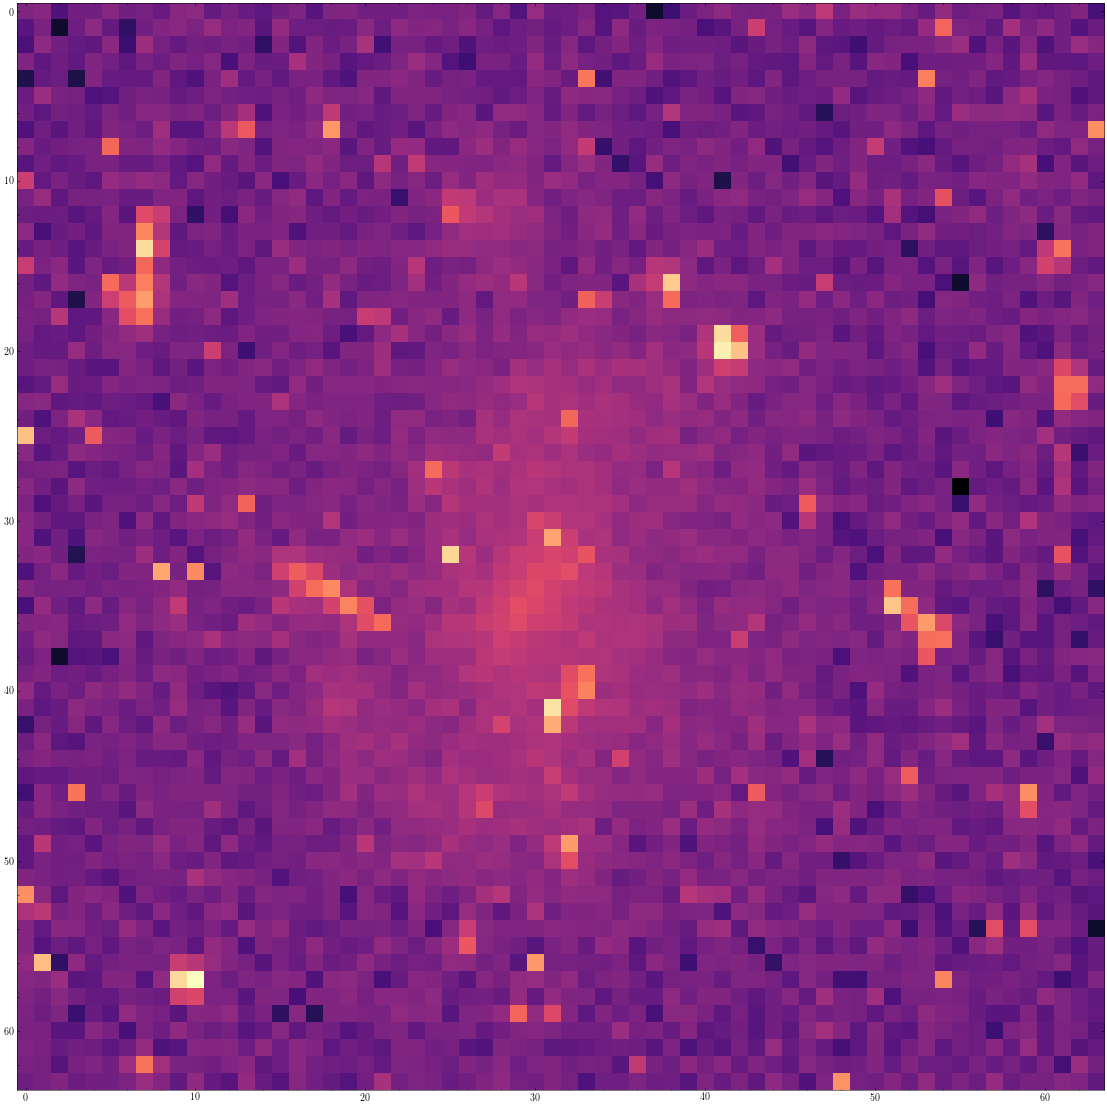

In [427]:
plt.figure(figsize=(20, 20))
# plt.imshow(cutouts1_raw[1].data/exptime + cutouts1_raw[2].data/exptime + cutouts1_raw[3].data/exptime, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))
plt.imshow(sum([c.data for c in cutouts3_raw])/exptime, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))

In [435]:

hdu1 = fits.PrimaryHDU(cutouts1_raw[0].data, header=cutouts1_raw[0].wcs.to_header())
hdu2 = fits.ImageHDU(cutouts1_raw[1].data, header=cutouts1_raw[1].wcs.to_header())
hdu3 = fits.ImageHDU(cutouts1_raw[2].data, header=cutouts1_raw[2].wcs.to_header())
hdu4 = fits.ImageHDU(cutouts1_raw[3].data, header=cutouts1_raw[3].wcs.to_header())
hdul = fits.HDUList([hdu1, hdu2, hdu3, hdu4])
hdul.writeto("connors_target1.fits")

In [436]:

hdu1 = fits.PrimaryHDU(cutouts2_raw[0].data, header=cutouts2_raw[0].wcs.to_header())
hdu2 = fits.ImageHDU(cutouts2_raw[1].data, header=cutouts2_raw[1].wcs.to_header())
hdu3 = fits.ImageHDU(cutouts2_raw[2].data, header=cutouts2_raw[2].wcs.to_header())
hdu4 = fits.ImageHDU(cutouts2_raw[3].data, header=cutouts2_raw[3].wcs.to_header())
hdul = fits.HDUList([hdu1, hdu2, hdu3, hdu4])
hdul.writeto("connors_target2.fits")

In [437]:

hdu1 = fits.PrimaryHDU(cutouts3_raw[0].data, header=cutouts3_raw[0].wcs.to_header())
hdu2 = fits.ImageHDU(cutouts3_raw[1].data, header=cutouts3_raw[1].wcs.to_header())
hdu3 = fits.ImageHDU(cutouts3_raw[2].data, header=cutouts3_raw[2].wcs.to_header())
hdu4 = fits.ImageHDU(cutouts3_raw[3].data, header=cutouts3_raw[3].wcs.to_header())
hdul = fits.HDUList([hdu1, hdu2, hdu3, hdu4])
hdul.writeto("connors_target3.fits")

# Find the star in each exposure, correct for pointing error

In [210]:
data = fits.open(path1)
wcs = WCS(data[1].header)
mean, median, std = sigma_clipped_stats(data[1].data,  sigma=200.0)
print(mean, median, std)
daofind = DAOStarFinder(fwhm=8.0, threshold=50.*std)
sources = daofind(data[1].data)
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
len(positions)

2517.2035115904796 2503.0 613.5004935559292


6

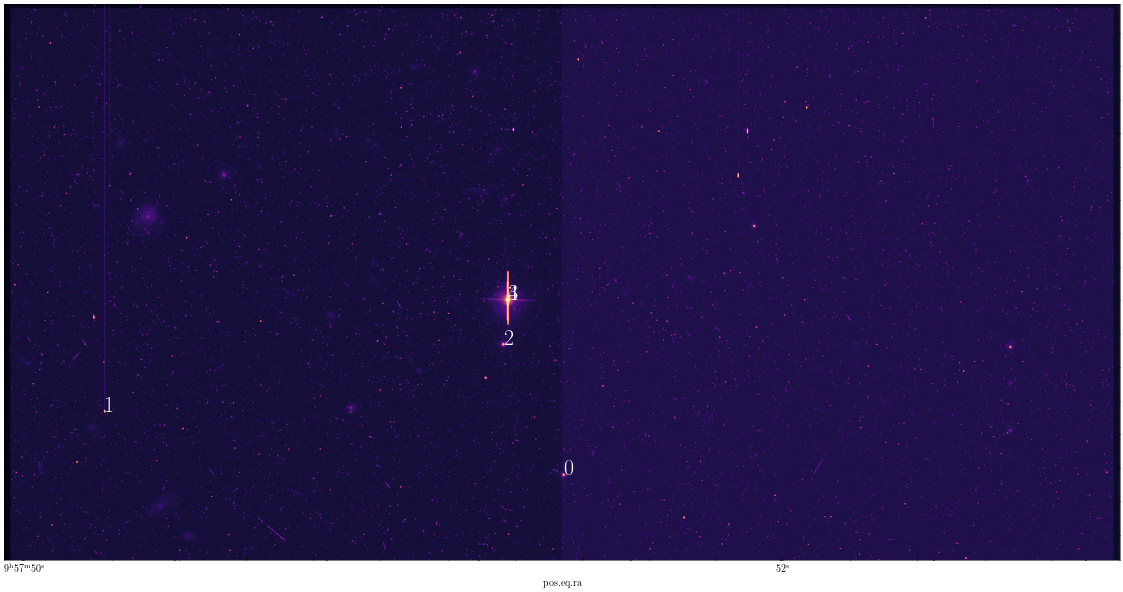

In [244]:

fig = plt.figure(figsize=(20, 20))
fig.add_subplot(projection=wcs)
plt.imshow(data[1].data, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))
# plt.colorbar()

for i, pos in enumerate(positions):
    plt.annotate(f"{i}", xy=pos, fontsize=22, color="w")

In [230]:
star_coords1 = []
for p in [path1, path2, path3, path4]:
    data = fits.open(p)
    wcs = WCS(data[1].header)
    mean, median, std = sigma_clipped_stats(data[1].data,  sigma=200.0)
    print(mean, median, std)
    daofind = DAOStarFinder(fwhm=8.0, threshold=50.*std)
    sources = daofind(data[1].data)
    positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
    star_coords1.append(positions[4])

2517.2035115904796 2503.0 613.5004935559292
2519.1077056479317 2502.0 631.1083555321155
2518.7983568329314 2503.0 632.6271962434218
2520.1203449278582 2508.0 604.2687387545786


In [243]:
star_coords1[0] - star_coords1[3]

array([  -5.48525926, -181.62696749])

# Check statistics of SLIC, looking at training data

In [17]:
path = "../data/MAST_2023-05-25T2105/HLA/hst_12210_71_acs_wfc_f814w/hst_12210_71_acs_wfc_f814w_drz.fits"
data = fits.open(path)

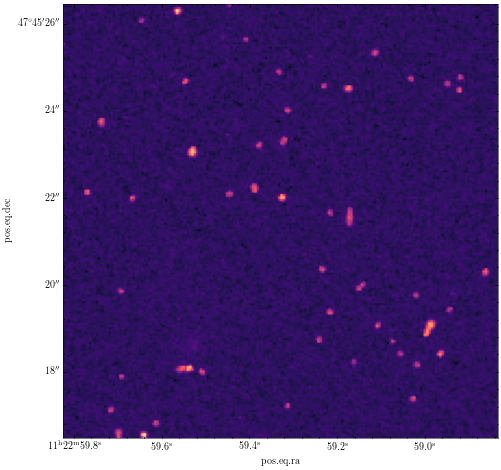

In [18]:
_wcs = WCS(data[1].header)

fig = plt.figure(figsize=(8, 8))
fig.add_subplot(projection=_wcs)
plt.imshow(data[1].data[2000:2200, 2000:2200], cmap="magma", norm=ImageNormalize(stretch=LogStretch()))

In [19]:
data[1].data.min()

-0.026431378

In [20]:
data[1].data.max()

231.2338

In [22]:
data[1].header["CD1_1"] * 3600

-0.049999999999996804

In [25]:
# data[0].header

In [46]:
path1 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybhq_raw.fits"
path2 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybkq_raw.fits"
path3 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybnq_raw.fits"
path4 = "../data/MAST_2023-05-25T19_44_42.921Z/HST/J8XIAY010/j8xiaybyq_raw.fits"

path = "../data/acs_I_095751+0228_unrot_sci_20.fits"
data = fits.open(path)
reference_wcs = WCS(data[0].header)

# Initialize the output with the WCS
driz = Drizzle(outwcs=reference_wcs)

# Combine the input images into on drizzle image
driz.add_fits_file(path1)


In [47]:
reference_wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 149.46484665  2.4824847  
CRPIX : 3750.0  3750.0  
CD1_1 CD1_2  : 1.4157228951629e-06  8.21219660800666e-06  
CD2_1 CD2_2  : 8.21219660800666e-06  -1.4157228951629e-06  
NAXIS : 7500  7500

In [48]:
driz.outwcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 149.46484665  2.4824847  
CRPIX : 3750.0  3750.0  
CD1_1 CD1_2  : 1.4157228951629e-06  8.21219660800666e-06  
CD2_1 CD2_2  : 8.21219660800666e-06  -1.4157228951629e-06  
NAXIS : 7500  7500

In [66]:
driz.outsci.max() / exptime

11.682385085367358

In [67]:
data[0].data.max()

44.898052

In [73]:
driz.outwcs.world_to_pixel(coord1_raw)

(array(1542.60322641), array(6698.52501799))

In [58]:
size = 64 * u.pixel
# wcs = WCS(data[4].header)
cutout = Cutout2D(driz.outsci, coord1_raw, size, wcs=wcs)

In [28]:
bias = fits.open(bias_path)
dark = fits.open(dark_path)

In [ ]:
bias[]